In [1]:
import xarray as xr

import numpy as np

import torch
import torch.nn as nn
import sys
sys.path.append("../")

import Utils.networks as networks
import Utils.data_functions as data_functions
import torch.distributed as dist
import Utils.time_steppers as time_steppers
import Utils.transformations as transformations
import Utils.normalization_values as normalization_values
import Utils.parallel as parallel

import os 
import random
import copy as copy
import importlib
import matplotlib.pyplot as plt

import cmocean as cm

In [2]:
# experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/Euler_Step_CM4_No_Scaling_2026-01-26/'
# experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/Direct_Step_CM4_Scaled_Resid_Fixed_2026-01-26/'
# experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/Direct_Step_CM4_Scaled_Resid_No_Dil_2026-01-26/'
# experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/Replicate_CESM2_Baseline_Correct_2026-03-10/'
# experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/Replicate_CESM2_Baseline_HFDS_2026-03-10/'
# experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/Replicate_CESM2_Holocene_Fixed_2026-03-10/'
# experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/Replicate_CESM2_Baseline_w_Vel_2026-03-13/'
experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/CM4_1pct_New_Dynamic_2026-03-16/'
# experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/CM4_1pct_New_Dynamic_ViT_Checkpoints_2026-03-20/'

# experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/Truly_Replicate_CESM2_Baseline_Exact_2026-03-12/'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/Direct_Step_CM4_No_Init_2026-01-19/'
# experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/Direct_Step_CM4_Scaled_Resid_Weaker_Constraint_2026-01-27/'
# experiment_path = '/pscratch/sd/a/asubel/Chapter_2/Networks/Direct_Step_CM4_Scaled_Resid_Weaker_Constraint_2026-01-27/'

device_name = 'cuda'

In [3]:
sys.path.append(experiment_path)
from Config import *
inv_norm_labels = transformations.inv_normalize(means = normalization_label_variables.means,stds = normalization_label_variables.stds)

In [4]:
# epoch = 'final'W
#TAUVO_MOSTLY OKAY 55
#TAUUO MOSTLY OKAY 58

epoch = 132
# best 51
# restart_restart 14
# restart 44
# 66 for HFDS
#29 best Euler Checkpoint
#71 best IVP

if epoch == 'final':    
    forward_model.network.load_state_dict(torch.load(experiment_path + 'Checkpoints/Model_Weights_final.pt',map_location=torch.device("cuda")))
else:
    try:
        forward_model.network.load_state_dict(torch.load(experiment_path + 'Checkpoints/Model_Weights_epoch_'+str(epoch)+'.pt',map_location=torch.device("cuda")))
    except:
        forward_model.network.load_state_dict(torch.load(experiment_path + 'Checkpoints/Checkpoint_epoch_'+str(epoch)+'.tar',map_location=torch.device("cuda"))['network_state'])


# forward_model.network.load_state_dict(torch.load('/pscratch/sd/a/asubel/Chapter_2/Networks/Direct_Step_CM4_Detrended_Finetuned_Fixed_2025-07-18/Checkpoints/Model_Weights_epoch_34.pt',map_location=torch.device("cuda"),weights_only=True))
# forward_model.network.load_state_dict(torch.load('/pscratch/sd/a/asubel/Chapter_2/Networks/Direct_Step_Holocene_Finetuning_2025-04-25/Checkpoints/Model_Weights_epoch_42.pt',map_location=torch.device("cuda"),weights_only=True))

forward_model.state_transform = transformations.NullTransform()
forward_model.update_device(device_name)
forward_model.network = forward_model.network.eval()

/tmp/ipykernel_927885/776870405.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  forward_model.network.load_state_dict(torch.load(experiment_path + 'Checkpoints/Model_We

In [5]:
# forward_model = time_steppers.DirectStep(
#     network=forward_model.network,
#     dt=1,
#     transform=forward_model.transform,
# )
# forward_model.update_device(device_name)

In [6]:
# wet_mask_tensor = wet_transformation_label.mask 

# # 2. Initialize the Operator
# # Choose a small coefficient (e.g., 0.001 to 0.05)
# diff_op = transformations.LaplacianDiffusion(channels=label_values_train.input_size,
#                                       diffusion_coeff=0.05, 
#                                       wet_mask=wet_mask_tensor,
#                                       device_name='cpu')

# forward_model = time_steppers.RK3StepDiffusion(
#     diffusion_module=diff_op,
#     network=forward_model.network,
#     dt=1,
#     transform=forward_model.transform,
# )
# forward_model.update_device(device_name)


In [7]:
# wet_mask_tensor = wet_transformation_label.mask 

# # 2. Initialize the Operator
# # Choose a small coefficient (e.g., 0.001 to 0.05)
# diff_op = transformations.LaplacianDiffusion(channels=label_values_train.input_size,
#                                       diffusion_coeff=0.05, 
#                                       wet_mask=wet_mask_tensor,
#                                       device_name='cpu')

# forward_model = time_steppers.EulerStepDiffusion(
#     diffusion_module=diff_op,
#     network=forward_model.network,
#     dt=1,
#     transform=forward_model.transform,
# )
# forward_model.update_device(device_name)


In [20]:


subsample = None

# time_slice_for_rollout = slice('0320-01-01','0335-02-01')
# time_slice_for_rollout = slice('0625-01-01','0675-02-01')
# time_slice_for_rollout = slice('0600-01-01','0650-02-01')
# time_slice_for_rollout = slice('0540-01-01','0640-02-01')

# time_slice_for_rollout = slice('0850-01-01','0900-02-01')
# time_slice_for_rollout = slice('0300-01-01','0315-02-01')
time_slice_for_rollout = slice('0250-01-01','0265-02-01')
# time_slice_for_rollout = slice('0595-01-01','0695-02-01')
# time_slice_for_rollout = slice('1100-01-01','1200-02-01')
# time_slice_for_rollout = slice('1100-01-01','1150-02-01')

time_offset = ''
# DATA_PATH = '/pscratch/sd/a/asubel/Data/Chapter_2/CESM2_piControl_w_tas.zarr/'
# DATA_PATH = '/pscratch/sd/a/asubel/Data/Chapter_2/CESM2_piControl_Detrended.zarr'
# DATA_PATH = '/pscratch/sd/a/asubel/Data/Chapter_2/Holocene_Processed_Detrended.zarr'
# DATA_PATH = '/pscratch/sd/a/asubel/Data/Chapter_2/CM4_CMIP_New_Detrended.zarr/'
# DATA_PATH = '/pscratch/sd/a/asubel/Data/Chapter_2/CESM2_piControl_more_levels.zarr/'
# DATA_PATH = '/pscratch/sd/a/asubel/Data/Chapter_2/CM4_CMIP_New_Below_500m.zarr'
# DATA_PATH = '/pscratch/sd/a/asubel/Data/Chapter_2/CM4_1pct.zarr'
DATA_PATH = '/pscratch/sd/a/asubel/Data/Chapter_2/CM4_1pct.zarr'
# DATA_PATH = '/pscratch/sd/a/asubel/Data/Chapter_2/CM4_1pct_Slow_Fast.zarr'

data = xr.open_zarr(DATA_PATH)#.sel(y=slice(-90,64))
if numerical_model == 'CM4':
    data = data.isel(lev = slice(0,-1))

if subsample != None:
    data = data.isel(time = slice(None,None,subsample))
data = data.sel(time = time_slice_for_rollout)
wet = (data.isel(time = 0)[label_variables]*0+1).drop_vars('time')
dates = data.time.values

In [21]:
if len(boundary_transformation.transformations) > 2:
    boundary_transformation.transformations = boundary_transformation.transformations[:2]

if not(boundary_variables) and include_radiation:
    boundary_values = data_functions.data_radiation(data,
                                                    transform = normalization_radiation,
                                                    max_steps = 1,
                                                    steps = 1,
                                                   )

elif boundary_variables:
    boundary_values = data_functions.data_from_single_source(data,
                                                             
                                                             boundary_variables,
                                                             transform = boundary_transformation,
                                                             max_steps = 1,
                                                             steps = 1,
                                                             )
    if include_radiation:
        orbital_parameters_6ka = {
            'ecc': 0.018682,
            'obliquity': 24.105,
            'long_peri': 180.87,
            }                
        orbital_parameters_1850 = {
            'ecc': 0.016764,
            'obliquity': 23.459,
            'long_peri': 280.33,
            }              

        if DATA_PATH == '/pscratch/sd/a/asubel/Data/Chapter_2/CESM2_piControl_Detrended.zarr':
            orbital_parameters = orbital_parameters_1850
        elif DATA_PATH == '/pscratch/sd/a/asubel/Data/Chapter_2/Holocene_Processed_Detrended.zarr':
            orbital_parameters = orbital_parameters_6ka       
        radiation_values = data_functions.data_radiation(data,
                                                        transform = normalization_radiation,
                                                        max_steps = 1,
                                                        steps = 1,
                                                         orb = orbital_parameters
                                                         
                                                       )    
        boundary_values = data_functions.MergedDatasets((boundary_values,radiation_values))
        
else:                                                             
    boundary_values = data_functions.data_from_single_source(data,
                                                               boundary_variables,
                                                               max_steps = 1,
                                                               steps = 1,
                                                              )       
if integrated_variables:
    
    integrated_values = data_functions.data_from_single_source(data,
                                                               integrated_variables,
                                                               transform = integrate_transformation,
                                                               max_steps = 1,      
                                                               steps = 1,
                                                              )
else:
    integrated_values =  data_functions.data_from_single_source(data,
                                                               integrated_variables,
                                                               max_steps = 1,
                                                               steps = 1,                                                                
                                                              )  
label_values =  data_functions.data_from_single_source(data,
                                                       label_variables,
                                                       max_steps = 1,      
                                                       steps = 1,
                                                       )

In [22]:
steps_per_save = 50
rollout_length = data.time.size - 1


import dask as dask
variable_list = label_variables
ds_temp = xr.Dataset(coords=data.isel(time=slice(1,rollout_length+1)).coords)

for var in variable_list:
    shape = data[var].shape
    shape = (rollout_length,) + shape[1:]
    ds_temp[var] = xr.DataArray(dask.array.zeros(shape ),dims = ('time','lev','y','x'))

ds_temp = ds_temp.chunk(chunks = {'time':5,
                             'x':ds_temp.x.size,
                             'y':ds_temp.y.size,
                             'lev':ds_temp.lev.size,
                            })

In [23]:
N_snapshots = boundary_values.size
include_epoch =  False

preds_save_path = '/pscratch/sd/a/asubel/Chapter_2/Preds/'


# prediction_name = 'BVP_piControl_w_Vel_Multistep_Euler'
# prediction_name = 'BVP_Holocene_w_Vel_Multistep'
# prediction_name = 'BVP_piControl_w_Vel_Multistep_Longer'
# prediction_name = 'BVP_piControl_w_Vel_Multistep_Smoothed'
# prediction_name = 'BVP_piControl_Multistep_Smoothed'
# prediction_name = 'BVP_piControl_Multistep_More_Levels'
# prediction_name = 'BVP_piControl_Deep_Ocean'
# prediction_name = 'RK3_Step_diffusion'
# prediction_name = 'Euler_to_RK3_Step_diffusion'
# prediction_name = 'RK3_Step_native_diffusion'
# prediction_name = 'Euler_Step_diffusion_54'
prediction_name = '1pct_new_weights_In_Sample'
# prediction_name = 'Initialized_1pct'
# prediction_name = 'CM4_Rollout_Euler_No_Scale'
# prediction_name = 'CM4_Reconstruct_Baseline_CESM2_piControl'
# prediction_name = 'CM4_Reconstruct_Holocene_CESM2_Holocene'
# 
# prediction_name = 'CM4_Rollout_Direct_Scaled_Direct'
# prediction_name = 'CM4_Rollout_Baseline'
# prediction_name = 'CM4_Reconstruct_Rollout_w_Vel_epoch_149'
# 


# prediction_name = 'BVP_CM4_Trend'



if include_epoch:
    prediction_name += '_' + str(epoch)
prediction_name += time_offset
prediction_name += '.zarr'

steps_per_save = 50

ds_temp.to_zarr(preds_save_path + prediction_name, compute = False,mode = 'w')
ds_temp[list(ds_temp.coords)].to_zarr(preds_save_path + prediction_name, mode = 'r+')

preds = torch.zeros((steps_per_save,) + label_values.input_shape)
tendencies = torch.zeros((steps_per_save,) + label_values.input_shape)
corrected_preds = torch.zeros((steps_per_save,) + label_values.input_shape)
save = True

write_mode = 'w' # 'w-'

with torch.no_grad():
    for i in range(rollout_length):
        if i == 0:
            out = forward_model.step_forward(integrated_values[0][0],boundary_values[0][0])            
        else:
            out = forward_model.step_forward(out,boundary_values[i][0])
            

        preds[i%steps_per_save] = out
        
        if i%steps_per_save == steps_per_save-1 or i == rollout_length-1:
            preds = inv_norm_labels(preds)
            
            index_start = 0
            pred_array = xr.Dataset(coords= ds_temp.isel(time = slice(i-i%steps_per_save,i+1)).coords)

            for var in label_variables:
                var_size = label_values.variable_size[var]
                if var_size == 1:
                    var_array = xr.DataArray(coords= ds_temp.isel(time = slice(i-i%steps_per_save,i+1))[['time','y','x']])
                else:
                    var_array = xr.DataArray(coords= ds_temp.isel(time = slice(i-i%steps_per_save,i+1))[['time','lev','y','x']])
      
                var_array.data = preds[:,index_start:index_start+var_size]
               
                pred_array[var] = var_array*wet[var]
                
                index_start += var_size
                pred_array = pred_array.chunk({'time':5,'lev':19})
            if save:
                pred_array.drop_vars(list(pred_array.coords.variables)).to_zarr(preds_save_path + prediction_name, region = {'time':slice(i-i%steps_per_save,i+1)})
                
            preds = torch.zeros((min(rollout_length-(i+1),steps_per_save),) + label_values.input_shape)

In [24]:
test_data = xr.open_zarr(preds_save_path + prediction_name)

In [25]:
# data['thetao'] = data['thetao_fast'] + data['thetao_slow']

# test_data['thetao'] = test_data['thetao_fast'] + test_data['thetao_slow']

In [26]:
# import cartopy.crs as ccrs
# layout = [
#     ['cbar_mean', 'plt_truth', 'plt_pred', 'plt_error', 'cbar_error'],
# ]
# map_axes_keys = [item for sublist in layout for item in sublist if 'cbar' not in item]
# per_subplot_kw = {key: {'projection': ccrs.PlateCarree()} for key in map_axes_keys}

# fig, axs = plt.subplot_mosaic(
#     layout,
#     figsize=(22, 3),
#     per_subplot_kw=per_subplot_kw,
#     gridspec_kw={'width_ratios': [0.05, 1, 1, 1, 0.05], 'wspace': 0.1, 'hspace': 0.2}
# )
# level = 0
# N_steps = 1200
# test_data['thetao_fast'][:N_steps,level].mean('time').plot(cbar_ax = axs['cbar_mean'] ,ax = axs['plt_pred'],
#                                                transform=ccrs.PlateCarree(),
#                                                vmin = -2,vmax= 32,
#                                                cmap = cm.cm.thermal,
#                                                cbar_kwargs = {'label' :r"$\theta_O$[$^o$C]", 'location':'left'})
# data['thetao_fast'][:N_steps,level].mean('time').plot(cbar_ax = axs['cbar_mean'] ,
#                                           transform=ccrs.PlateCarree(),
#                                           ax = axs['plt_truth'],vmin = -2,vmax= 32,
#                                           cmap = cm.cm.thermal,
#                                           cbar_kwargs = {'label' :r"$\theta_O$[$^o$C]", 'location':'left'})
# (test_data['thetao_fast']-data['thetao_fast'])[:N_steps,level].mean('time').plot(cbar_ax = axs['cbar_error'] ,
#                                                                 ax = axs['plt_error'],
#                                                                 vmin = -1,vmax= 1,
#                                                                 cmap = cm.cm.diff,
#                                                                 cbar_kwargs = {'label' :r"Error [$^o$C]", 'location':'right'})
# axs['plt_truth'].set_title('CM4')
# axs['plt_pred'].set_title('Emulator Rollout')
# axs['plt_error'].set_title('Error (Emulator Rollout - CM4)')

# for index in map_axes_keys:
#     axs[index].coastlines()
#     gl = axs[index].gridlines(draw_labels=True, color='gray', alpha=0, linestyle='--')
    
#     # By default, turn off labels on the top and right of all plots
#     gl.top_labels = False
#     gl.right_labels = False
    
#     # Only draw the y-axis (latitude) labels on the leftmost plot
#     if index != 'plt_truth':
#         gl.left_labels = False

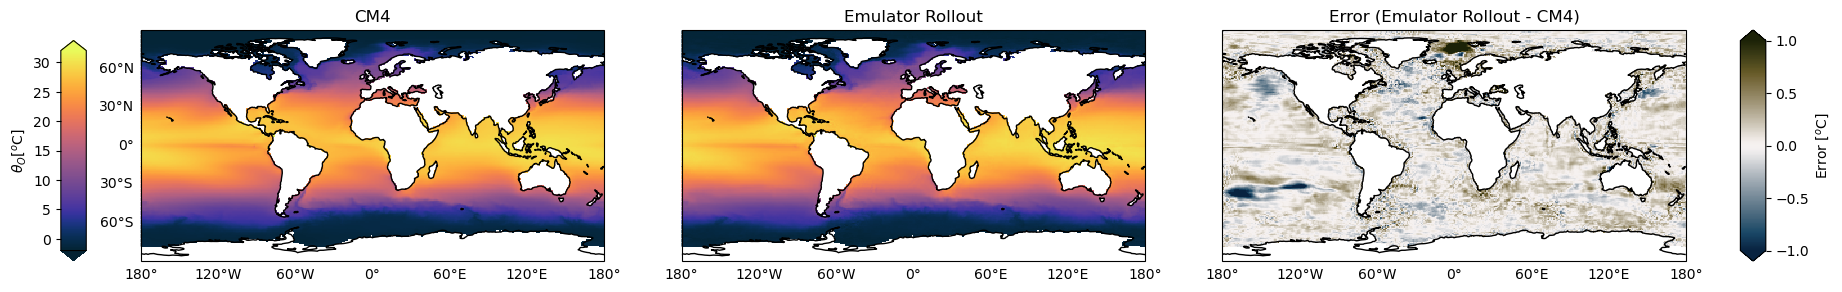

In [27]:
import cartopy.crs as ccrs
layout = [
    ['cbar_mean', 'plt_truth', 'plt_pred', 'plt_error', 'cbar_error'],
]
map_axes_keys = [item for sublist in layout for item in sublist if 'cbar' not in item]
per_subplot_kw = {key: {'projection': ccrs.PlateCarree()} for key in map_axes_keys}

fig, axs = plt.subplot_mosaic(
    layout,
    figsize=(22, 3),
    per_subplot_kw=per_subplot_kw,
    gridspec_kw={'width_ratios': [0.05, 1, 1, 1, 0.05], 'wspace': 0.1, 'hspace': 0.2}
)
level = 1
N_steps = 1200
test_data['thetao'][:N_steps,level].mean('time').plot(cbar_ax = axs['cbar_mean'] ,ax = axs['plt_pred'],
                                               transform=ccrs.PlateCarree(),
                                               vmin = -2,vmax= 32,
                                               cmap = cm.cm.thermal,
                                               cbar_kwargs = {'label' :r"$\theta_O$[$^o$C]", 'location':'left'})
data['thetao'][:N_steps,level].mean('time').plot(cbar_ax = axs['cbar_mean'] ,
                                          transform=ccrs.PlateCarree(),
                                          ax = axs['plt_truth'],vmin = -2,vmax= 32,
                                          cmap = cm.cm.thermal,
                                          cbar_kwargs = {'label' :r"$\theta_O$[$^o$C]", 'location':'left'})
(test_data['thetao']-data['thetao'])[:N_steps,level].mean('time').plot(cbar_ax = axs['cbar_error'] ,
                                                                ax = axs['plt_error'],
                                                                vmin = -1,vmax= 1,
                                                                cmap = cm.cm.diff,
                                                                cbar_kwargs = {'label' :r"Error [$^o$C]", 'location':'right'})
axs['plt_truth'].set_title('CM4')
axs['plt_pred'].set_title('Emulator Rollout')
axs['plt_error'].set_title('Error (Emulator Rollout - CM4)')

for index in map_axes_keys:
    axs[index].coastlines()
    gl = axs[index].gridlines(draw_labels=True, color='gray', alpha=0, linestyle='--')
    
    # By default, turn off labels on the top and right of all plots
    gl.top_labels = False
    gl.right_labels = False
    
    # Only draw the y-axis (latitude) labels on the leftmost plot
    if index != 'plt_truth':
        gl.left_labels = False

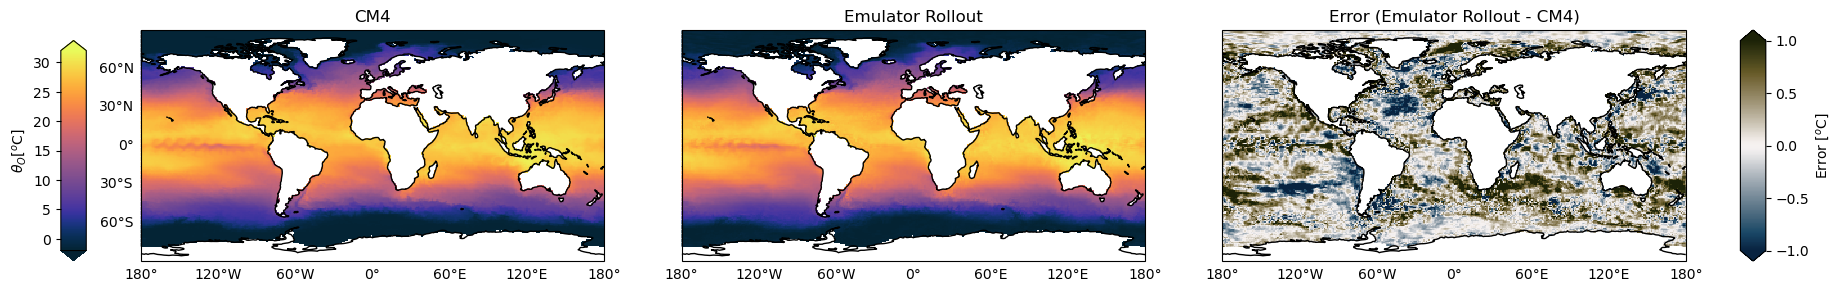

In [28]:
import cartopy.crs as ccrs
layout = [
    ['cbar_mean', 'plt_truth', 'plt_pred', 'plt_error', 'cbar_error'],
]
map_axes_keys = [item for sublist in layout for item in sublist if 'cbar' not in item]
per_subplot_kw = {key: {'projection': ccrs.PlateCarree()} for key in map_axes_keys}

fig, axs = plt.subplot_mosaic(
    layout,
    figsize=(22, 3),
    per_subplot_kw=per_subplot_kw,
    gridspec_kw={'width_ratios': [0.05, 1, 1, 1, 0.05], 'wspace': 0.1, 'hspace': 0.2}
)
level = 0
N_start = 500
N_steps = 501
test_data['thetao'][N_start:N_steps,level].mean('time').plot(cbar_ax = axs['cbar_mean'] ,ax = axs['plt_pred'],
                                               transform=ccrs.PlateCarree(),
                                               vmin = -2,vmax= 32,
                                               cmap = cm.cm.thermal,
                                               cbar_kwargs = {'label' :r"$\theta_O$[$^o$C]", 'location':'left'})
data['thetao'][N_start:N_steps,level].mean('time').plot(cbar_ax = axs['cbar_mean'] ,
                                          transform=ccrs.PlateCarree(),
                                          ax = axs['plt_truth'],vmin = -2,vmax= 32,
                                          cmap = cm.cm.thermal,
                                          cbar_kwargs = {'label' :r"$\theta_O$[$^o$C]", 'location':'left'})
(test_data['thetao']-data['thetao'])[N_start:N_steps,level].mean('time').plot(cbar_ax = axs['cbar_error'] ,
                                                                ax = axs['plt_error'],
                                                                vmin = -1,vmax= 1,
                                                                cmap = cm.cm.diff,
                                                                cbar_kwargs = {'label' :r"Error [$^o$C]", 'location':'right'})
axs['plt_truth'].set_title('CM4')
axs['plt_pred'].set_title('Emulator Rollout')
axs['plt_error'].set_title('Error (Emulator Rollout - CM4)')

for index in map_axes_keys:
    axs[index].coastlines()
    gl = axs[index].gridlines(draw_labels=True, color='gray', alpha=0, linestyle='--')
    
    # By default, turn off labels on the top and right of all plots
    gl.top_labels = False
    gl.right_labels = False
    
    # Only draw the y-axis (latitude) labels on the leftmost plot
    if index != 'plt_truth':
        gl.left_labels = False

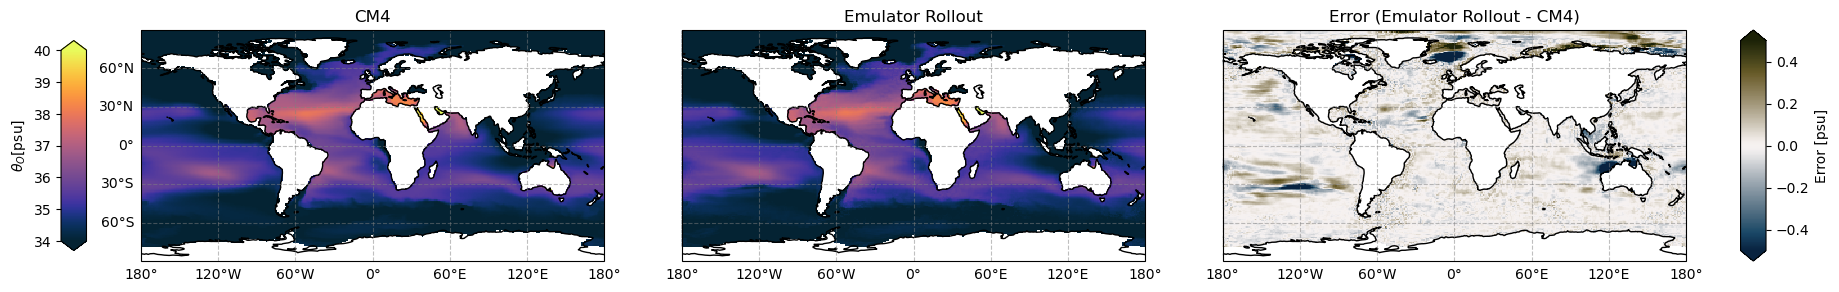

In [29]:
import cartopy.crs as ccrs
layout = [
    ['cbar_mean', 'plt_truth', 'plt_pred', 'plt_error', 'cbar_error'],
]
map_axes_keys = [item for sublist in layout for item in sublist if 'cbar' not in item]
per_subplot_kw = {key: {'projection': ccrs.PlateCarree()} for key in map_axes_keys}

fig, axs = plt.subplot_mosaic(
    layout,
    figsize=(22, 3),
    per_subplot_kw=per_subplot_kw,
    gridspec_kw={'width_ratios': [0.05, 1, 1, 1, 0.05], 'wspace': 0.1, 'hspace': 0.2}
)
level = 2

test_data['so'][:,level].mean('time').plot(cbar_ax = axs['cbar_mean'] ,ax = axs['plt_pred'],
                                               transform=ccrs.PlateCarree(),
                                               vmin = 34,vmax= 40,
                                               cmap = cm.cm.thermal,
                                               cbar_kwargs = {'label' :r"$\theta_O$[psu]", 'location':'left'})
data['so'][:,level].mean('time').plot(cbar_ax = axs['cbar_mean'] ,
                                          transform=ccrs.PlateCarree(),
                                          ax = axs['plt_truth'],vmin = 34,vmax= 40,
                                          cmap = cm.cm.thermal,
                                          cbar_kwargs = {'label' :r"$\theta_O$[psu]", 'location':'left'})
(test_data['so']-data['so'])[:,level].mean('time').plot(cbar_ax = axs['cbar_error'] ,
                                                                ax = axs['plt_error'],
                                                                vmin = -.5,vmax= .5,
                                                                cmap = cm.cm.diff,
                                                                cbar_kwargs = {'label' :r"Error [psu]", 'location':'right'})
axs['plt_truth'].set_title('CM4')
axs['plt_pred'].set_title('Emulator Rollout')
axs['plt_error'].set_title('Error (Emulator Rollout - CM4)')

for index in map_axes_keys:
    axs[index].coastlines()
    gl = axs[index].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    
    # By default, turn off labels on the top and right of all plots
    gl.top_labels = False
    gl.right_labels = False
    
    # Only draw the y-axis (latitude) labels on the leftmost plot
    if index != 'plt_truth':
        gl.left_labels = False

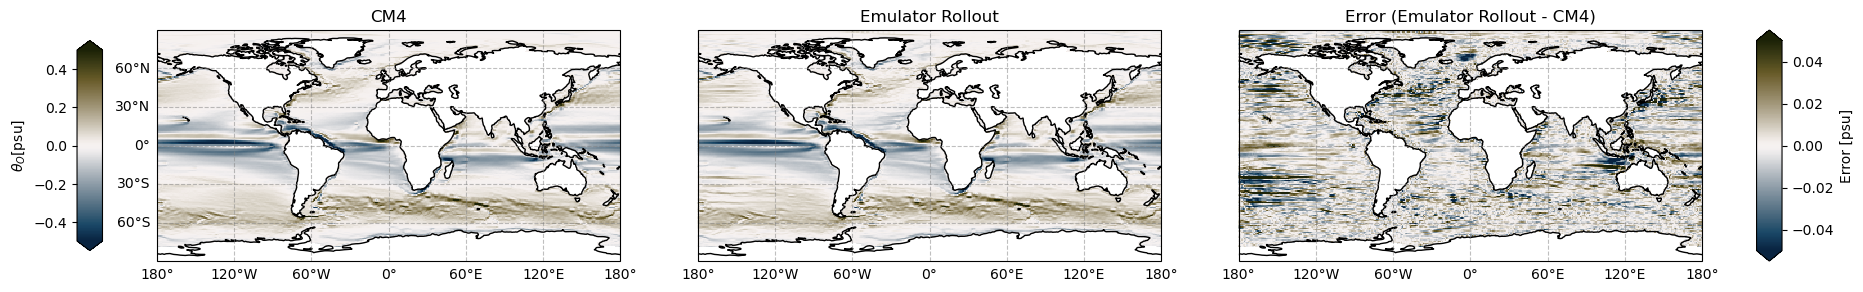

In [30]:
import cartopy.crs as ccrs

layout = [
    ['cbar_mean', 'plt_truth', 'plt_pred', 'plt_error', 'cbar_error'],
]

map_axes_keys = [item for sublist in layout for item in sublist if 'cbar' not in item]
per_subplot_kw = {key: {'projection': ccrs.PlateCarree()} for key in map_axes_keys}

fig, axs = plt.subplot_mosaic(
    layout,
    figsize=(22, 3),
    per_subplot_kw=per_subplot_kw,
    gridspec_kw={'width_ratios': [0.05, 1, 1, 1, 0.05], 'wspace': 0.1, 'hspace': 0.2}
)
level = 0

test_data['uo'][:,level].mean('time').plot(cbar_ax = axs['cbar_mean'] ,ax = axs['plt_pred'],
                                               transform=ccrs.PlateCarree(),
                                               vmin = -.5,vmax= .5,
                                               cmap = cm.cm.diff,
                                               cbar_kwargs = {'label' :r"$\theta_O$[psu]", 'location':'left'})
data['uo'][:,level].mean('time').plot(cbar_ax = axs['cbar_mean'] ,
                                          transform=ccrs.PlateCarree(),
                                          ax = axs['plt_truth'],vmin = -.5,vmax= .5,
                                          cmap = cm.cm.diff,
                                          cbar_kwargs = {'label' :r"$\theta_O$[psu]", 'location':'left'})
(test_data['uo']-data['uo'])[:,level].mean('time').plot(cbar_ax = axs['cbar_error'] ,
                                                                ax = axs['plt_error'],
                                                                vmin = -.05,vmax= .05,
                                                                cmap = cm.cm.diff,
                                                                cbar_kwargs = {'label' :r"Error [psu]", 'location':'right'})
axs['plt_truth'].set_title('CM4')
axs['plt_pred'].set_title('Emulator Rollout')
axs['plt_error'].set_title('Error (Emulator Rollout - CM4)')

for index in map_axes_keys:
    axs[index].coastlines()
    gl = axs[index].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    
    # By default, turn off labels on the top and right of all plots
    gl.top_labels = False
    gl.right_labels = False
    
    # Only draw the y-axis (latitude) labels on the leftmost plot
    if index != 'plt_truth':
        gl.left_labels = False

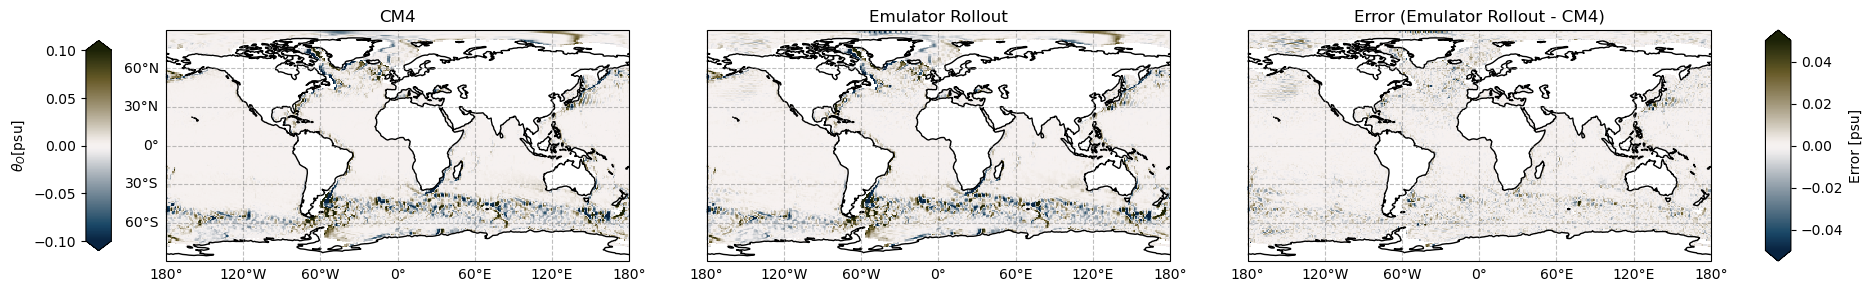

In [31]:
import cartopy.crs as ccrs
layout = [
    ['cbar_mean', 'plt_truth', 'plt_pred', 'plt_error', 'cbar_error'],
]
map_axes_keys = [item for sublist in layout for item in sublist if 'cbar' not in item]
per_subplot_kw = {key: {'projection': ccrs.PlateCarree()} for key in map_axes_keys}

fig, axs = plt.subplot_mosaic(
    layout,
    figsize=(22, 3),
    per_subplot_kw=per_subplot_kw,
    gridspec_kw={'width_ratios': [0.05, 1, 1, 1, 0.05], 'wspace': 0.1, 'hspace': 0.2}
)
level = 10

test_data['vo'][:,level].mean('time').plot(cbar_ax = axs['cbar_mean'] ,ax = axs['plt_pred'],
                                               transform=ccrs.PlateCarree(),
                                               vmin = -.1,vmax= .1,
                                               cmap = cm.cm.diff,
                                               cbar_kwargs = {'label' :r"$\theta_O$[psu]", 'location':'left'})
data['vo'][:,level].mean('time').plot(cbar_ax = axs['cbar_mean'] ,
                                          transform=ccrs.PlateCarree(),
                                          ax = axs['plt_truth'],vmin = -.1,vmax= .1,
                                          cmap = cm.cm.diff,
                                          cbar_kwargs = {'label' :r"$\theta_O$[psu]", 'location':'left'})
(test_data['vo']-data['vo'])[:,level].mean('time').plot(cbar_ax = axs['cbar_error'] ,
                                                                ax = axs['plt_error'],
                                                                vmin = -.05,vmax= .05,
                                                                cmap = cm.cm.diff,
                                                                cbar_kwargs = {'label' :r"Error [psu]", 'location':'right'})
axs['plt_truth'].set_title('CM4')
axs['plt_pred'].set_title('Emulator Rollout')
axs['plt_error'].set_title('Error (Emulator Rollout - CM4)')

for index in map_axes_keys:
    axs[index].coastlines()
    gl = axs[index].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    
    # By default, turn off labels on the top and right of all plots
    gl.top_labels = False
    gl.right_labels = False
    
    # Only draw the y-axis (latitude) labels on the leftmost plot
    if index != 'plt_truth':
        gl.left_labels = False